# Copy-Paste Selection Analysis

This notebook compares the object selection behavior of two augmentation runs:

- Random copy-paste: `results/18_random_cp`
- Score-guided copy-paste: `results/05_copy_paste_exp`

The goal is to verify three claims from the generated augmentation outputs:

1. Score-guided mean object area is smaller than random.
2. Score-guided unique object count is lower than random.
3. Score-guided mean score is higher than random.

The notebook reads the augmentation metadata files, normalizes the selected-object records into tables, computes summary statistics, runs one-sided tests, and exports figures and reports.

In [6]:
from __future__ import annotations

import json
import math
import random
import statistics
from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path
from typing import Iterable

import pandas as pd

try:
    from PIL import Image
except ImportError as exc:
    raise SystemExit("Pillow is required. Install it with: pip install pillow") from exc

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise SystemExit("matplotlib is required. Install it with: pip install matplotlib") from exc

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")
RANDOM_RUN = {
    "run_id": "random",
    "use_score_guidance": False,
    "experiment_dir": PROJECT_ROOT / "results" / "18_random_cp",
}
GUIDED_RUN = {
    "run_id": "score_guided",
    "use_score_guidance": True,
    "experiment_dir": PROJECT_ROOT / "results" / "05_copy_paste_exp",
}

RUN_SPECS = [RANDOM_RUN, GUIDED_RUN]
OUTPUT_DIR = PROJECT_ROOT / "results" / "copy_paste_selection_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for spec in RUN_SPECS:
    spec["metadata_dir"] = spec["experiment_dir"] / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "metadata"
    spec["score_file"] = spec["experiment_dir"] / "Step_3_Scoring_Dataset" / "score_results.json"
    if not spec["metadata_dir"].exists():
        raise FileNotFoundError(f"Missing metadata directory: {spec['metadata_dir']}")
    if not spec["score_file"].exists():
        raise FileNotFoundError(f"Missing score file: {spec['score_file']}")

print("Loaded input paths:")
for spec in RUN_SPECS:
    print(f"- {spec['run_id']}: {spec['metadata_dir']}")
    print(f"  score file: {spec['score_file']}")

Loaded input paths:
- random: /home/khanh/Projects/DifficultyAgri/results/18_random_cp/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/metadata
  score file: /home/khanh/Projects/DifficultyAgri/results/18_random_cp/Step_3_Scoring_Dataset/score_results.json
- score_guided: /home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/metadata
  score file: /home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_3_Scoring_Dataset/score_results.json


In [7]:
@lru_cache(maxsize=None)
def load_image_size(image_path: str) -> tuple[int, int]:
    with Image.open(image_path) as img:
        return int(img.width), int(img.height)


def object_area_px2(image_path: str, bbox_yolo: Iterable[float]) -> float:
    bbox = list(bbox_yolo)
    if len(bbox) != 4:
        raise ValueError(f"bbox_yolo must have 4 values, got {bbox}")
    _, _, width, height = [float(value) for value in bbox]
    image_width, image_height = load_image_size(str(image_path))
    return float(width * height * image_width * image_height)


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def load_score_file(path: Path) -> dict:
    payload = load_json(path)
    if "image_difficulties" not in payload:
        raise ValueError(f"Unexpected score file schema: {path}")
    return payload


def normalize_metadata_file(metadata_path: Path, run_id: str, use_score_guidance: bool) -> tuple[list[dict], dict]:
    payload = load_json(metadata_path)
    selected_objects = payload.get("selected_objects")
    if not isinstance(selected_objects, list):
        raise ValueError(f"Invalid metadata schema in {metadata_path}: missing selected_objects list")

    rows: list[dict] = []
    object_keys: list[str] = []
    image_id = payload.get("background_image_name", metadata_path.stem)

    for selected in selected_objects:
        if not isinstance(selected, dict):
            raise ValueError(f"Invalid object entry in {metadata_path}")
        required_fields = ["source_image_name", "source_image_path", "source_object_index", "score", "bbox_yolo"]
        missing_fields = [field for field in required_fields if field not in selected]
        if missing_fields:
            raise ValueError(f"Missing fields {missing_fields} in {metadata_path}")

        source_image_name = str(selected["source_image_name"])
        source_object_index = int(selected["source_object_index"])
        source_image_path = str(selected["source_image_path"])
        bbox_yolo = selected["bbox_yolo"]
        object_score = float(selected["score"])
        object_area = object_area_px2(source_image_path, bbox_yolo)
        object_key = f"{source_image_name}:{source_object_index}"
        object_keys.append(object_key)

        rows.append(
            {
                "run_id": run_id,
                "use_score_guidance": bool(use_score_guidance),
                "metadata_file": metadata_path.name,
                "image_id": image_id,
                "source_image_name": source_image_name,
                "source_object_index": source_object_index,
                "object_id": object_key,
                "object_area_px2": float(object_area),
                "object_score": object_score,
            }
        )

    image_summary = {
        "run_id": run_id,
        "use_score_guidance": bool(use_score_guidance),
        "metadata_file": metadata_path.name,
        "image_id": image_id,
        "n_selected_objects": len(rows),
        "mean_area_px2": float(statistics.mean([row["object_area_px2"] for row in rows])) if rows else float("nan"),
        "mean_score": float(statistics.mean([row["object_score"] for row in rows])) if rows else float("nan"),
        "unique_count": len(set(object_keys)),
        "min_score": float(min([row["object_score"] for row in rows])) if rows else float("nan"),
        "max_score": float(max([row["object_score"] for row in rows])) if rows else float("nan"),
    }
    return rows, image_summary


def load_run_tables(run_spec: dict) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    score_payload = load_score_file(run_spec["score_file"])
    object_rows: list[dict] = []
    image_rows: list[dict] = []
    for metadata_path in sorted(run_spec["metadata_dir"].glob("*.json")):
        rows, image_summary = normalize_metadata_file(
            metadata_path=metadata_path,
            run_id=run_spec["run_id"],
            use_score_guidance=run_spec["use_score_guidance"],
        )
        object_rows.extend(rows)
        image_rows.append(image_summary)

    object_df = pd.DataFrame(object_rows)
    image_df = pd.DataFrame(image_rows)

    if object_df.empty:
        raise RuntimeError(f"No object rows were loaded for {run_spec['run_id']}")
    if image_df.empty:
        raise RuntimeError(f"No image rows were loaded for {run_spec['run_id']}")

    object_df["object_area_px2"] = pd.to_numeric(object_df["object_area_px2"], errors="coerce")
    object_df["object_score"] = pd.to_numeric(object_df["object_score"], errors="coerce")
    object_df = object_df.dropna(subset=["object_area_px2", "object_score", "object_id"])
    object_df = object_df[object_df["object_area_px2"] > 0].copy()

    image_df["mean_area_px2"] = pd.to_numeric(image_df["mean_area_px2"], errors="coerce")
    image_df["mean_score"] = pd.to_numeric(image_df["mean_score"], errors="coerce")
    image_df["unique_count"] = pd.to_numeric(image_df["unique_count"], errors="coerce")
    image_df = image_df.dropna(subset=["mean_area_px2", "mean_score", "unique_count"])

    object_df = object_df.drop_duplicates(
        subset=["run_id", "metadata_file", "object_id", "object_area_px2", "object_score"],
        keep="first",
    )

    return object_df, image_df, score_payload


run_tables = {}
score_file_overview_rows = []
for spec in RUN_SPECS:
    object_df, image_df, score_payload = load_run_tables(spec)
    run_tables[spec["run_id"]] = {
        "object_df": object_df,
        "image_df": image_df,
        "score_payload": score_payload,
    }
    score_file_overview_rows.append(
        {
            "run_id": spec["run_id"],
            "use_score_guidance": spec["use_score_guidance"],
            "score_file": str(spec["score_file"]),
            "score_weight_mode": score_payload.get("scoring_weight_mode"),
            "selected_object_weight": score_payload.get("selected_object_weight"),
            "selected_false_positive_weight": score_payload.get("selected_false_positive_weight"),
            "n_scored_images": len(score_payload.get("image_difficulties", [])),
            "n_selected_objects": int(len(object_df)),
            "n_augmented_images": int(len(image_df)),
        }
    )

score_file_overview_df = pd.DataFrame(score_file_overview_rows)
score_file_overview_df

,run_id,use_score_guidance,score_file,score_weight_mode,selected_object_weight,selected_false_positive_weight,n_scored_images,n_selected_objects,n_augmented_images
0,random,False,/home/khanh/Projects/DifficultyAgri/results/18_random_cp/Step_3_Scoring_Dataset/score_results.json,balance_correlation,0.9,0.940552,536,2686,536
1,score_guided,True,/home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_3_Scoring_Dataset/score_results.json,balance_correlation,0.9,0.940552,536,2700,536


## Normalize object-level records and compute per-run metrics

The tables below turn every selected object into a single record. From there, the notebook computes per-image summaries and run-level metrics for the random and score-guided conditions.

In [8]:
def summarize_mode(object_df: pd.DataFrame, image_df: pd.DataFrame) -> dict:
    return {
        "n_images": int(len(image_df)),
        "n_selected_objects": int(len(object_df)),
        "mean_area_px2": float(object_df["object_area_px2"].mean()),
        "mean_score": float(object_df["object_score"].mean()),
        "unique_count_total": int(object_df["object_id"].nunique()),
        "min_score": float(object_df["object_score"].min()),
        "max_score": float(object_df["object_score"].max()),
        "per_image_mean_area_px2": float(image_df["mean_area_px2"].mean()),
        "per_image_mean_score": float(image_df["mean_score"].mean()),
        "per_image_unique_count_mean": float(image_df["unique_count"].mean()),
        "per_image_unique_count_median": float(image_df["unique_count"].median()),
        "per_image_unique_count_iqr": float(image_df["unique_count"].quantile(0.75) - image_df["unique_count"].quantile(0.25)),
        "per_image_area_median": float(image_df["mean_area_px2"].median()),
        "per_image_area_iqr": float(image_df["mean_area_px2"].quantile(0.75) - image_df["mean_area_px2"].quantile(0.25)),
        "per_image_score_median": float(image_df["mean_score"].median()),
        "per_image_score_iqr": float(image_df["mean_score"].quantile(0.75) - image_df["mean_score"].quantile(0.25)),
    }


mode_summary_rows = []
for spec in RUN_SPECS:
    tables = run_tables[spec["run_id"]]
    summary = summarize_mode(tables["object_df"], tables["image_df"])
    summary.update({
        "run_id": spec["run_id"],
        "use_score_guidance": spec["use_score_guidance"],
    })
    mode_summary_rows.append(summary)

mode_summary_df = pd.DataFrame(mode_summary_rows).set_index("run_id")
mode_summary_df

,n_images,n_selected_objects,mean_area_px2,mean_score,unique_count_total,min_score,max_score,per_image_mean_area_px2,per_image_mean_score,per_image_unique_count_mean,per_image_unique_count_median,per_image_unique_count_iqr,per_image_area_median,per_image_area_iqr,per_image_score_median,per_image_score_iqr,use_score_guidance
run_id,,,,,,,,,,,,,,,,,
random,536,2686,1479.167801,0.000000,2192,0.000000,0.0,1480.606424,0.0000,5.011194,5.0,4.0,1452.320423,256.394503,0.000000,0.000000,False
score_guided,536,2700,1420.297295,0.191011,1849,0.071439,1.0,1416.857851,0.1891,5.037313,5.0,4.0,1383.124410,224.575143,0.173085,0.060609,True


## Print requested selection logs

This section reproduces the exact logging format you requested for the score-guided and random conditions.

In [9]:
random_summary = mode_summary_df.loc["random"]
guided_summary = mode_summary_df.loc["score_guided"]

print("Random selected objects:")
print(f"  Mean object area: {random_summary['mean_area_px2']:.1f} px²")
print(f"  Mean score: {random_summary['mean_score']:.3f}")
print(f"  Unique objects used: {int(random_summary['unique_count_total'])}")

print()
print("Score-guided selected objects:")
print(f"  Mean object area: {guided_summary['mean_area_px2']:.1f} px²")
print(f"  Mean score: {guided_summary['mean_score']:.3f}")
print(f"  Unique objects used: {int(guided_summary['unique_count_total'])}")
print(f"  Score distribution: min={guided_summary['min_score']:.3f}, max={guided_summary['max_score']:.3f}")

Random selected objects:
  Mean object area: 1479.2 px²
  Mean score: 0.000
  Unique objects used: 2192

Score-guided selected objects:
  Mean object area: 1420.3 px²
  Mean score: 0.191
  Unique objects used: 1849
  Score distribution: min=0.071, max=1.000


## Build comparison table and run significance tests

This section compares the two conditions with deltas, relative change, bootstrap confidence intervals, and one-sided tests for the three verification claims.

In [11]:
def mean_of(df: pd.DataFrame, column: str) -> float:
    return float(df[column].mean())


def bootstrap_ci_diff(left: list[float], right: list[float], n_boot: int = 5000, seed: int = 123) -> tuple[float, float]:
    rng = random.Random(seed)
    left = list(left)
    right = list(right)
    samples = []
    for _ in range(n_boot):
        left_sample = [rng.choice(left) for _ in left]
        right_sample = [rng.choice(right) for _ in right]
        samples.append(statistics.mean(right_sample) - statistics.mean(left_sample))
    samples.sort()
    lower_index = int(0.025 * (n_boot - 1))
    upper_index = int(0.975 * (n_boot - 1))
    return float(samples[lower_index]), float(samples[upper_index])


def bootstrap_unique_total_ci(left_df: pd.DataFrame, right_df: pd.DataFrame, n_boot: int = 3000, seed: int = 123) -> tuple[float, float]:
    rng = random.Random(seed)
    left_groups = list(left_df.groupby("metadata_file"))
    right_groups = list(right_df.groupby("metadata_file"))
    left_keys = [set(group[1]["object_id"].tolist()) for group in left_groups]
    right_keys = [set(group[1]["object_id"].tolist()) for group in right_groups]

    diffs = []
    for _ in range(n_boot):
        left_sample = [rng.choice(left_keys) for _ in left_keys]
        right_sample = [rng.choice(right_keys) for _ in right_keys]
        left_total = len(set().union(*left_sample)) if left_sample else 0
        right_total = len(set().union(*right_sample)) if right_sample else 0
        diffs.append(right_total - left_total)

    diffs.sort()
    lower_index = int(0.025 * (n_boot - 1))
    upper_index = int(0.975 * (n_boot - 1))
    return float(diffs[lower_index]), float(diffs[upper_index])


def permutation_test(left: list[float], right: list[float], alternative: str, n_perm: int = 5000, seed: int = 123) -> tuple[float, float]:
    rng = random.Random(seed)
    left = list(left)
    right = list(right)
    observed = statistics.mean(right) - statistics.mean(left)
    combined = left + right
    count = 0
    for _ in range(n_perm):
        rng.shuffle(combined)
        left_sample = combined[: len(left)]
        right_sample = combined[len(left) :]
        diff = statistics.mean(right_sample) - statistics.mean(left_sample)
        if alternative == "less" and diff <= observed:
            count += 1
        elif alternative == "greater" and diff >= observed:
            count += 1
    p_value = (count + 1) / (n_perm + 1)
    return float(observed), float(p_value)


def permutation_test_unique_total(left_df: pd.DataFrame, right_df: pd.DataFrame, alternative: str, n_perm: int = 3000, seed: int = 123) -> tuple[float, float]:
    rng = random.Random(seed)
    left_groups = [group[1] for group in left_df.groupby("metadata_file")]
    right_groups = [group[1] for group in right_df.groupby("metadata_file")]
    combined_groups = left_groups + right_groups
    left_n = len(left_groups)

    def total_unique(groups: list[pd.DataFrame]) -> int:
        keys = set()
        for group in groups:
            keys.update(group["object_id"].tolist())
        return len(keys)

    observed = total_unique(right_groups) - total_unique(left_groups)
    count = 0
    for _ in range(n_perm):
        shuffled = combined_groups[:]
        rng.shuffle(shuffled)
        left_sample = shuffled[:left_n]
        right_sample = shuffled[left_n:]
        diff = total_unique(right_sample) - total_unique(left_sample)
        if alternative == "less" and diff <= observed:
            count += 1
        elif alternative == "greater" and diff >= observed:
            count += 1
    p_value = (count + 1) / (n_perm + 1)
    return float(observed), float(p_value)


def cohens_d(left: list[float], right: list[float]) -> float:
    left = list(left)
    right = list(right)
    if len(left) < 2 or len(right) < 2:
        return float("nan")
    left_mean = statistics.mean(left)
    right_mean = statistics.mean(right)
    left_var = statistics.pvariance(left)
    right_var = statistics.pvariance(right)
    pooled = math.sqrt(((len(left) - 1) * left_var + (len(right) - 1) * right_var) / (len(left) + len(right) - 2))
    if pooled == 0:
        return float("nan")
    return float((right_mean - left_mean) / pooled)


random_object_df = run_tables["random"]["object_df"]
guided_object_df = run_tables["score_guided"]["object_df"]
random_image_df = run_tables["random"]["image_df"]
guided_image_df = run_tables["score_guided"]["image_df"]

comparison_rows = []

area_ci = bootstrap_ci_diff(random_object_df["object_area_px2"].tolist(), guided_object_df["object_area_px2"].tolist())
area_obs, area_p = permutation_test(random_object_df["object_area_px2"].tolist(), guided_object_df["object_area_px2"].tolist(), alternative="less")
comparison_rows.append(
    {
        "metric": "mean object area (px²)",
        "random": float(random_object_df["object_area_px2"].mean()),
        "score_guided": float(guided_object_df["object_area_px2"].mean()),
        "absolute_delta": float(guided_object_df["object_area_px2"].mean() - random_object_df["object_area_px2"].mean()),
        "relative_change_pct": float((guided_object_df["object_area_px2"].mean() - random_object_df["object_area_px2"].mean()) / random_object_df["object_area_px2"].mean() * 100.0),
        "bootstrap_95_ci_delta": area_ci,
        "observed_delta": area_obs,
        "p_value": area_p,
        "effect_size_cohens_d": cohens_d(random_object_df["object_area_px2"].tolist(), guided_object_df["object_area_px2"].tolist()),
    }
)

score_ci = bootstrap_ci_diff(random_object_df["object_score"].tolist(), guided_object_df["object_score"].tolist())
score_obs, score_p = permutation_test(random_object_df["object_score"].tolist(), guided_object_df["object_score"].tolist(), alternative="greater")
comparison_rows.append(
    {
        "metric": "mean score",
        "random": float(random_object_df["object_score"].mean()),
        "score_guided": float(guided_object_df["object_score"].mean()),
        "absolute_delta": float(guided_object_df["object_score"].mean() - random_object_df["object_score"].mean()),
        "relative_change_pct": float("nan"),
        "bootstrap_95_ci_delta": score_ci,
        "observed_delta": score_obs,
        "p_value": score_p,
        "effect_size_cohens_d": cohens_d(random_object_df["object_score"].tolist(), guided_object_df["object_score"].tolist()),
    }
)

unique_ci = bootstrap_unique_total_ci(random_object_df, guided_object_df)
unique_obs, unique_p = permutation_test_unique_total(random_object_df, guided_object_df, alternative="less")
comparison_rows.append(
    {
        "metric": "unique objects used",
        "random": int(random_object_df["object_id"].nunique()),
        "score_guided": int(guided_object_df["object_id"].nunique()),
        "absolute_delta": int(guided_object_df["object_id"].nunique() - random_object_df["object_id"].nunique()),
        "relative_change_pct": float((guided_object_df["object_id"].nunique() - random_object_df["object_id"].nunique()) / random_object_df["object_id"].nunique() * 100.0),
        "bootstrap_95_ci_delta": unique_ci,
        "observed_delta": unique_obs,
        "p_value": unique_p,
        "effect_size_cohens_d": float("nan"),
    }
)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["bootstrap_95_ci_delta"] = comparison_df["bootstrap_95_ci_delta"].apply(lambda x: f"[{x[0]:.3f}, {x[1]:.3f}]")
comparison_df

,metric,random,score_guided,absolute_delta,relative_change_pct,bootstrap_95_ci_delta,observed_delta,p_value,effect_size_cohens_d
0,mean object area (px²),1479.167801,1420.297295,-58.870505,-3.979975,"[-81.976, -35.302]",-58.870505,0.000200,-0.135107
1,mean score,0.000000,0.191011,0.191011,NaN,"[0.187, 0.195]",0.191011,0.000200,2.320891
2,unique objects used,2192.000000,1849.000000,-343.000000,-15.647810,"[-249.000, -73.000]",-343.000000,0.000333,NaN


In [13]:
from IPython.display import display

comparison_df = comparison_df.copy()
comparison_df.loc[comparison_df["metric"] == "mean score", "relative_change_pct"] = float("nan")


def verdict_ci_bounds(ci_text: str) -> tuple[float, float]:
    left_text, right_text = ci_text.strip("[]").split(",")
    return float(left_text), float(right_text)


verdict_rows = [
    {
        "claim": "Score-guided mean object area is smaller than random",
        "alternative": "guided < random",
        "observed_delta": float(area_obs),
        "p_value": float(area_p),
        "bootstrap_ci_delta": area_ci,
        "effect_size_cohens_d": float(
            comparison_df.loc[comparison_df["metric"] == "mean object area (px²)", "effect_size_cohens_d"].iloc[0]
        ),
        "supported": bool(area_p < 0.05 and area_ci[1] < 0),
    },
    {
        "claim": "Score-guided unique object count is smaller than random",
        "alternative": "guided < random",
        "observed_delta": float(unique_obs),
        "p_value": float(unique_p),
        "bootstrap_ci_delta": unique_ci,
        "effect_size_cohens_d": None,
        "supported": bool(unique_p < 0.05 and unique_ci[1] < 0),
    },
    {
        "claim": "Score-guided mean score is higher than random",
        "alternative": "guided > random",
        "observed_delta": float(score_obs),
        "p_value": float(score_p),
        "bootstrap_ci_delta": score_ci,
        "effect_size_cohens_d": float(
            comparison_df.loc[comparison_df["metric"] == "mean score", "effect_size_cohens_d"].iloc[0]
        ),
        "supported": bool(score_p < 0.05 and score_ci[0] > 0),
    },
]

verdict_df = pd.DataFrame(verdict_rows)
verdict_df["bootstrap_ci_delta"] = verdict_df["bootstrap_ci_delta"].apply(lambda x: f"[{x[0]:.3f}, {x[1]:.3f}]")
verdict_df["p_value_bonferroni"] = (verdict_df["p_value"] * len(verdict_df)).clip(upper=1.0)


def supported_after_bonferroni(row: pd.Series) -> bool:
    ci_low, ci_high = verdict_ci_bounds(row["bootstrap_ci_delta"])
    if row["claim"].endswith("smaller than random"):
        return bool(row["p_value_bonferroni"] < 0.05 and ci_high < 0)
    if row["claim"].endswith("higher than random"):
        return bool(row["p_value_bonferroni"] < 0.05 and ci_low > 0)
    return False


verdict_df["supported_after_bonferroni"] = verdict_df.apply(supported_after_bonferroni, axis=1)

print("Corrected comparison table:")
display(comparison_df)
print("\nCorrected verdict table:")
display(verdict_df)

Corrected comparison table:


,metric,random,score_guided,absolute_delta,relative_change_pct,bootstrap_95_ci_delta,observed_delta,p_value,effect_size_cohens_d
0,mean object area (px²),1479.167801,1420.297295,-58.870505,-3.979975,"[-81.976, -35.302]",-58.870505,0.000200,-0.135107
1,mean score,0.000000,0.191011,0.191011,NaN,"[0.187, 0.195]",0.191011,0.000200,2.320891
2,unique objects used,2192.000000,1849.000000,-343.000000,-15.647810,"[-249.000, -73.000]",-343.000000,0.000333,NaN



Corrected verdict table:


,claim,alternative,observed_delta,p_value,bootstrap_ci_delta,effect_size_cohens_d,supported,p_value_bonferroni,supported_after_bonferroni
0,Score-guided mean object area is smaller than random,guided < random,-58.870505,0.000200,"[-81.976, -35.302]",-0.135107,True,0.0006,True
1,Score-guided unique object count is smaller than random,guided < random,-343.000000,0.000333,"[-249.000, -73.000]",NaN,True,0.0010,True
2,Score-guided mean score is higher than random,guided > random,0.191011,0.000200,"[0.187, 0.195]",2.320891,True,0.0006,True


## Visualize distributions and export artifacts

The final section saves the summary table, significance report, and figures to disk, and produces plots for the area, score, and diversity comparisons.

/tmp/ipykernel_1408751/703357160.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_series, guided_series], labels=["Random", "Score-guided"], showfliers=False)
/tmp/ipykernel_1408751/703357160.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_series, guided_series], labels=["Random", "Score-guided"], showfliers=False)
/tmp/ipykernel_1408751/703357160.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_series, guided_series], labels=["Random", "Score-guided"], showfliers=False)


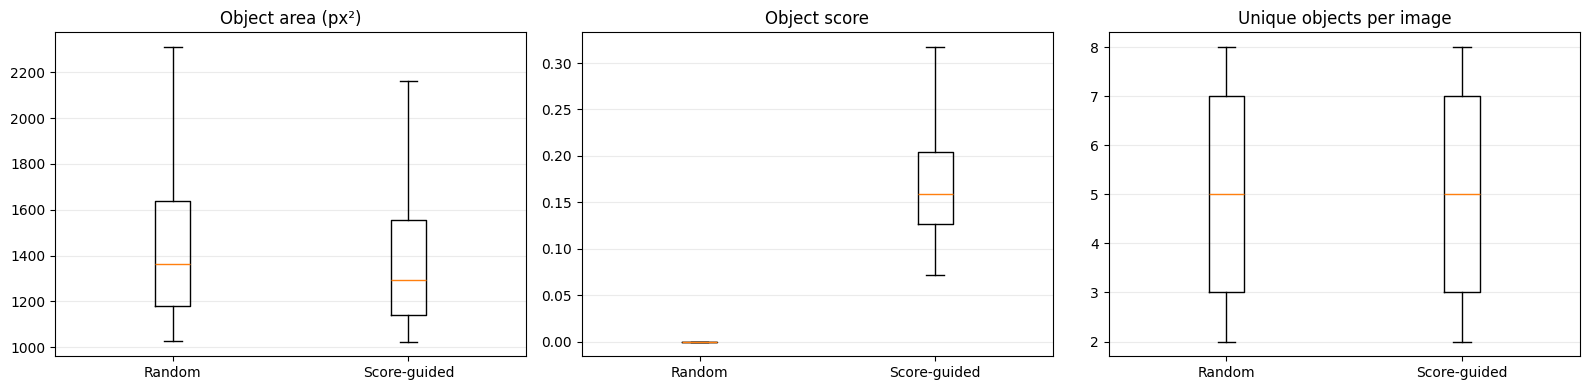

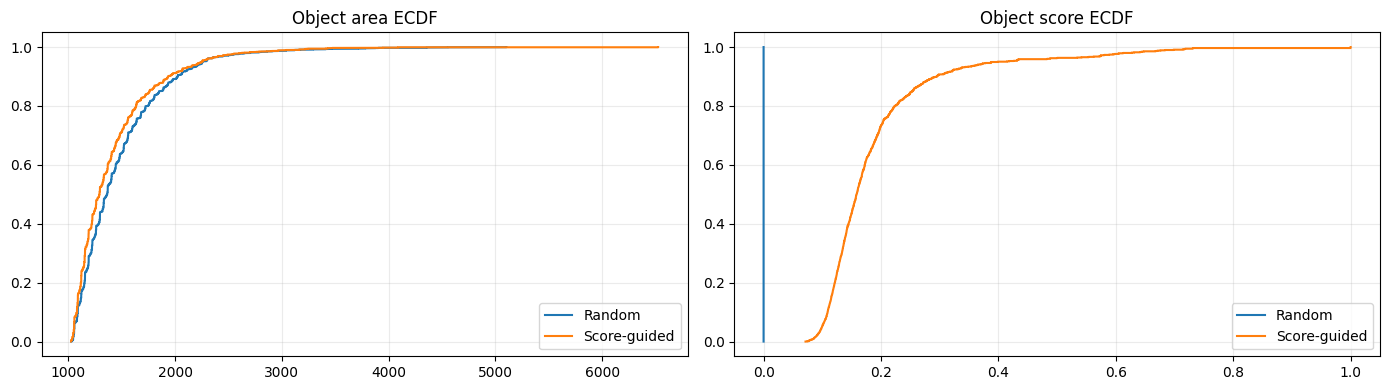

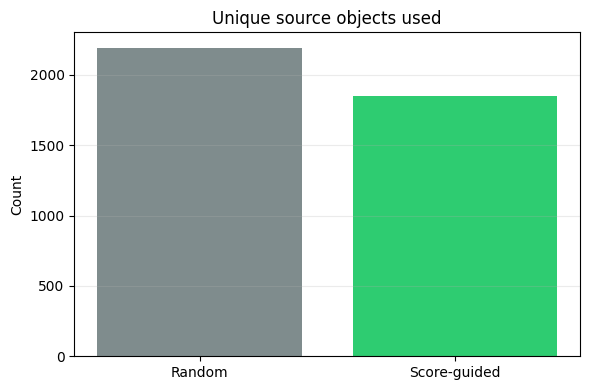

Comparison table:


,metric,random,score_guided,absolute_delta,relative_change_pct,bootstrap_95_ci_delta,observed_delta,p_value,effect_size_cohens_d
0,mean object area (px²),1479.167801,1420.297295,-58.870505,-3.979975,"[-81.976, -35.302]",-58.870505,0.000200,-0.135107
1,mean score,0.000000,0.191011,0.191011,NaN,"[0.187, 0.195]",0.191011,0.000200,2.320891
2,unique objects used,2192.000000,1849.000000,-343.000000,-15.647810,"[-249.000, -73.000]",-343.000000,0.000333,NaN



Verdict table:


,claim,alternative,observed_delta,p_value,bootstrap_ci_delta,effect_size_cohens_d,supported,p_value_bonferroni,supported_after_bonferroni
0,Score-guided mean object area is smaller than random,guided < random,-58.870505,0.000200,"[-81.976, -35.302]",-0.135107,True,0.0006,True
1,Score-guided unique object count is smaller than random,guided < random,-343.000000,0.000333,"[-249.000, -73.000]",NaN,True,0.0010,True
2,Score-guided mean score is higher than random,guided > random,0.191011,0.000200,"[0.187, 0.195]",2.320891,True,0.0006,True



Exported outputs to: /home/khanh/Projects/DifficultyAgri/results/copy_paste_selection_analysis
Parquet saved: False
Figures:
- boxplots: /home/khanh/Projects/DifficultyAgri/results/copy_paste_selection_analysis/boxplots.png
- ecdf: /home/khanh/Projects/DifficultyAgri/results/copy_paste_selection_analysis/ecdf.png
- unique_bar: /home/khanh/Projects/DifficultyAgri/results/copy_paste_selection_analysis/unique_count_bar.png


In [15]:
summary_table_path = OUTPUT_DIR / "comparison_table.csv"
summary_markdown_path = OUTPUT_DIR / "comparison_table.md"
test_report_path = OUTPUT_DIR / "test_report.json"
cleaned_csv_path = OUTPUT_DIR / "cleaned_object_records.csv"
cleaned_parquet_path = OUTPUT_DIR / "cleaned_object_records.parquet"

object_frames = [run_tables[spec["run_id"]]["object_df"] for spec in RUN_SPECS]
image_frames = [run_tables[spec["run_id"]]["image_df"] for spec in RUN_SPECS]
all_object_df = pd.concat(object_frames, ignore_index=True)
all_image_df = pd.concat(image_frames, ignore_index=True)

all_object_df.to_csv(cleaned_csv_path, index=False)
try:
    all_object_df.to_parquet(cleaned_parquet_path, index=False)
    parquet_saved = True
except Exception:
    parquet_saved = False

comparison_df.to_csv(summary_table_path, index=False)


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    headers = list(df.columns)
    lines = [
        "| " + " | ".join(str(header) for header in headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, row in df.iterrows():
        values = [str(row[header]) for header in headers]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


with open(summary_markdown_path, "w", encoding="utf-8") as handle:
    handle.write(dataframe_to_markdown(comparison_df))

claim_rows = verdict_df.to_dict(orient="records")

with open(test_report_path, "w", encoding="utf-8") as handle:
    json.dump(
        {
            "source_runs": [
                {
                    "run_id": spec["run_id"],
                    "metadata_dir": str(spec["metadata_dir"]),
                    "score_file": str(spec["score_file"]),
                }
                for spec in RUN_SPECS
            ],
            "comparison_table_path": str(summary_table_path),
            "comparison_markdown_path": str(summary_markdown_path),
            "cleaned_csv_path": str(cleaned_csv_path),
            "cleaned_parquet_path": str(cleaned_parquet_path),
            "parquet_saved": parquet_saved,
            "claims": claim_rows,
        },
        handle,
        indent=2,
    )

figures = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_specs = [
    ("object_area_px2", "Object area (px²)"),
    ("object_score", "Object score"),
    ("unique_count", "Unique objects per image"),
]
for ax, (column, title) in zip(axes, plot_specs):
    random_series = random_image_df[column] if column == "unique_count" else random_object_df[column]
    guided_series = guided_image_df[column] if column == "unique_count" else guided_object_df[column]
    ax.boxplot([random_series, guided_series], labels=["Random", "Score-guided"], showfliers=False)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig_path = OUTPUT_DIR / "boxplots.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
figures["boxplots"] = fig_path
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (column, title) in zip(axes, [("object_area_px2", "Object area ECDF"), ("object_score", "Object score ECDF")]):
    left = random_object_df[column].sort_values().to_numpy()
    right = guided_object_df[column].sort_values().to_numpy()
    for values, label in [(left, "Random"), (right, "Score-guided")]:
        y = [(i + 1) / len(values) for i in range(len(values))]
        ax.step(values, y, where="post", label=label)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
ecdf_path = OUTPUT_DIR / "ecdf.png"
fig.savefig(ecdf_path, dpi=200, bbox_inches="tight")
figures["ecdf"] = ecdf_path
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
unique_means = [random_summary["unique_count_total"], guided_summary["unique_count_total"]]
ax.bar(["Random", "Score-guided"], unique_means, color=["#7f8c8d", "#2ecc71"])
ax.set_title("Unique source objects used")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
unique_path = OUTPUT_DIR / "unique_count_bar.png"
fig.savefig(unique_path, dpi=200, bbox_inches="tight")
figures["unique_bar"] = unique_path
plt.show()

print("Comparison table:")
display(comparison_df)
print("\nVerdict table:")
display(verdict_df)
print(f"\nExported outputs to: {OUTPUT_DIR}")
print(f"Parquet saved: {parquet_saved}")
print("Figures:")
for name, path in figures.items():
    print(f"- {name}: {path}")